# CUTI replacing QW for EK_t

In [1]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
lati2,lati1 = -17,-4
mask_km = 250

In [3]:
def coastal_band_mask_rossby(ds, var='u10', R1=None):
    """
    Create a coastal band mask where the width at each latitude
    equals the local first baroclinic Rossby radius.

    Parameters
    ----------
    ds : xr.Dataset
    var : str
    R1 : xr.DataArray
        Rossby radius in km with a 'lat' coordinate.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlon = np.abs(lon_vals[1] - lon_vals[0])

    band = np.zeros_like(valid2d, dtype=bool)

    for j in range(valid2d.shape[0]):
        row = valid2d[j, :]
        ocean_cols = np.where(row)[0]
        if len(ocean_cols) == 0:
            continue

        i_coast = ocean_cols[-1]

        # Interpolate R1 to this latitude
        target_width_km = float(R1.interp(lat=lat_vals[j], method='nearest'))
        if np.isnan(target_width_km):
            continue

        A = 6371.0
        dx_km = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(dlon)
        n_cells = int(np.round(target_width_km / dx_km))

        i_start = max(i_coast - n_cells, 0)
        band[j, i_start:i_coast + 1] = True

    band = band & valid2d

    da_mask = xr.DataArray(band, dims=('lat', 'lon'),
                           coords={'lat': ds['lat'], 'lon': ds['lon']})
    return da_mask

In [4]:
def coastal_band_mask(ds, var='u10', target_width_km=111):
    """
    Create a coastal band mask with uniform cross-shore width in km.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlon = np.abs(lon_vals[1] - lon_vals[0])  # grid spacing in degrees

    # Find coastline (easternmost valid cell per row)
    band = np.zeros_like(valid2d, dtype=bool)

    for j in range(valid2d.shape[0]):
        row = valid2d[j, :]
        ocean_cols = np.where(row)[0]
        if len(ocean_cols) == 0:
            continue

        # Coast = easternmost valid cell
        i_coast = ocean_cols[-1]

        # How many cells = target_width_km at this latitude?
        A = 6371.0  # km
        dx_km = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(dlon)
        n_cells = int(np.round(target_width_km / dx_km))

        # Fill n_cells westward from coast
        i_start = max(i_coast - n_cells, 0)
        band[j, i_start:i_coast + 1] = True

    # Only keep cells that are actually ocean
    band = band & valid2d

    da_mask = xr.DataArray(band, dims=('lat', 'lon'),
                           coords={'lat': ds['lat'], 'lon': ds['lon']})
    return da_mask

In [5]:
def lat_band_mean(f, lat_top_start=-4, lat_top_end=-17):
    """
    Jacox-style box average: area-weighted mean over each 1° band.
    """
    A = 6371000.0
    results = []
    lat_band_centers = []

    for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
        lat_south = lat_north - 1
        f_band = f.sel(lat=slice(lat_south, lat_north))

        if f_band.sizes.get("lat", 0) == 0:
            continue

        # Compute cell areas as weights (dx varies with latitude)
        lat_vals = f_band.lat.values
        dlon = np.abs(np.diff(f_band.lon.values[:2])[0]) if len(f_band.lon) > 1 else 0.08
        dlat = np.abs(np.diff(lat_vals[:2])[0]) if len(lat_vals) > 1 else 0.08

        # Area of each cell: dx(lat) * dy
        cos_lat = np.cos(np.deg2rad(lat_vals))
        cell_area = A * np.deg2rad(dlat) * A * cos_lat * np.deg2rad(dlon)
        weights = xr.DataArray(cell_area, dims='lat', coords={'lat': lat_vals})

        # Area-weighted mean over lat and lon
        f_weighted = f_band.weighted(weights).mean(dim=('lat', 'lon'))
        results.append(f_weighted)
        lat_band_centers.append(0.5 * (lat_south + lat_north))

    f_out = xr.concat(results, dim="lat_band")
    f_out = f_out.assign_coords(lat_band=np.array(lat_band_centers))
    return f_out

In [6]:
def get_boundary_lons(ds, var='WMLD', target_width_km=111, lon_slice=None, lat_slice=None):
    """
    Applies coastal masking, spatial slicing, and calculates boundary longitudes.
    
    Parameters:
    ds: xarray.Dataset or DataArray
    var: str, variable name to analyze
    target_width_km: int, width for the coastal_band_mask
    lon_slice: slice, e.g., slice(-85, None)
    lat_slice: slice, e.g., slice(-17, -4)
    """
    # 1. Apply the coastal band mask (assuming this function is defined in your environment)
    mask = coastal_band_mask(ds, var=var, target_width_km=target_width_km)
    
    # 2. Select region and apply mask
    # We slice first, then mask to keep the operations light
    ds_subset = ds.sel(lon=lon_slice, lat=lat_slice)
    data = ds_subset[var].where(mask).isel(time=0)
    
    # 3. Vectorized boundary finding
    valid = data.notnull()
    
    # Find edges using shift
    valid_e = valid.shift(lon=-1).fillna(False)
    valid_w = valid.shift(lon=1).fillna(False)
    
    coast_mask = valid & (~valid_e)      # Easternmost valid cell
    offshore_mask = valid & (~valid_w)   # Westernmost valid cell
    
    # Extract longitudes
    coast_lons = data.lon.where(coast_mask).min(dim='lon')
    offshore_lons = data.lon.where(offshore_mask).min(dim='lon')
    
    return coast_lons, offshore_lons

In [7]:
# without longitude dimension
def lat_band_mean_(
    f,
    lat_top_start=-4,
    lat_top_end=-17,
):
    """
    Compute the mean of f for successive 1° latitude bands.

    Parameters
    ----------
    f : xarray.DataArray
        Must have a 'lat' dimension (and optionally time/lon/etc.).
    lat_top_start : float or int
        Northern latitude of the first band (e.g. -5).
    lat_top_end : float or int
        Northern latitude of the last band (e.g. -16).

    Returns
    -------
    f_band : xarray.DataArray
        Mean of f for each 1° band, with new dimension 'lat_band'.
        Any other original dimensions (e.g. time) are preserved.
    """

    results = []
    lat_band_centers = []

    for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
        lat_south = lat_north - 1

        # 1° band slice
        f_band = f.sel(lat=slice(lat_south, lat_north))

        # skip bands with no points
        if f_band.sizes.get("lat", 0) == 0:
            continue

        results.append(f_band.mean(dim='lat'))
        lat_band_centers.append(0.5 * (lat_south + lat_north))

    # concat over bands
    f_out = xr.concat(results, dim="lat_band")
    f_out = f_out.assign_coords(lat_band=np.array(lat_band_centers))

    return f_out

In [8]:
def transport_band(w_da, lat_top_start=-4, lat_top_end=-17):
    """
    Calculates the integrated transport (m2/s) per latitude band.
    Integrates over Longitude (W * dx) and averages over Latitude (Jacox-style).
    """
    R = 6371000.0
    results = []
    lat_band_centers = []

    # # 1. Ensure we are working with the mean over time first if needed
    # if 'time' in w_da.dims:
    #     w_da = w_da.mean('time')

    # 2. Extract resolution (assuming regular grid)
    dlon_deg = np.abs(w_da.lon[1] - w_da.lon[0]).values
    dlat_deg = np.abs(w_da.lat[1] - w_da.lat[0]).values
    
    # Radians for distance math
    dlon_rad = np.deg2rad(dlon_deg)
    dlat_rad = np.deg2rad(dlat_deg)

    for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
        lat_south = lat_north - 1
        # Slice the 1-degree band
        w_band = w_da.sel(lat=slice(lat_south, lat_north)).fillna(0)

        if w_band.sizes.get("lat", 0) == 0:
            continue

        # --- STEP A: Calculate dx and Transport (m2/s) ---
        # dx varies with latitude: R * cos(lat) * dlon
        cos_lat = np.cos(np.deg2rad(w_band.lat))
        dx = R * cos_lat * dlon_rad
        
        # Transport per cell = w * dx (Units: m/s * m = m2/s)
        transport_per_cell = w_band * dx
        
        # Integrate over Longitude (Sum along the offshore distance L)
        # Result: A 1D array across the 'lat' dimension within this band
        total_lon_transport = transport_per_cell.sum(dim='lon')

        # --- STEP B: Jacox-style Latitude Averaging ---
        # We average these latitude strips to get one value for the 1-degree band.
        # Weight by dy (though dy is constant, we use the standard area-weighting logic)
        dy = R * dlat_rad
        # In a 1-degree band, weights are essentially constant dy, but we keep it formal:
        weights = xr.DataArray(np.full_like(w_band.lat, dy), dims='lat', coords={'lat': w_band.lat})
        
        band_mean_transport = total_lon_transport.weighted(weights).mean(dim='lat')

        results.append(band_mean_transport)
        lat_band_centers.append(0.5 * (lat_south + lat_north))

    # Combine bands
    transport_out = xr.concat(results, dim="lat_band")
    transport_out = transport_out.assign_coords(lat_band=np.array(lat_band_centers))
    
    return transport_out

In [9]:
# ============================================================
# 2. Load data and apply mask
# ============================================================
ds = xr.open_dataset('winds_and_components_corrected.nc')
mask = coastal_band_mask(ds, var='Uek_geo', target_width_km=mask_km)  # ~250 km cross-shore
wind_coastal = ds.where(mask).sel(lon=slice(-85, None), lat=slice(lati2, lati1))

In [10]:
## Ekman transport

Ek_t = xr.open_dataset('Winds_components_Lu.nc').U_ek_cross.isel(offshore=0).compute()
Ek_t = (Ek_t.swap_dims({'coast_point': 'lat'})
         .drop_vars(['coast_point', 'lon', 'bearing', 'distance', 'f', 'offshore'])
         .rename('Ek_t'))
Ek_t

<xarray.DataArray 'Ek_t' (time: 432, lat: 159)> Size: 550kB
array([[1.09936991, 1.13629932, 1.18267682, ..., 1.38029691, 1.4905408 ,
        1.61628462],
       [0.98497617, 1.00166065, 1.03502389, ..., 0.55176081, 0.63042936,
        0.72468545],
       [0.95796447, 0.97392853, 1.00368189, ..., 0.09567068, 0.16782467,
        0.24495986],
       ...,
       [1.64549395, 1.69826302, 1.7661083 , ..., 2.96548421, 3.08481632,
        3.21032296],
       [1.59706691, 1.64387749, 1.70237792, ..., 2.94121349, 3.10352424,
        3.27706339],
       [1.38111402, 1.43295952, 1.4955133 , ..., 2.54178771, 2.66900788,
        2.80614894]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Attributes:
    units:      m^2/s
    long_name:  Cross-shore Ekman transport (BUI)

100%|███████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 4112.99it/s]


<xarray.DataArray 'Ek_t' (lat_band: 13, time: 432)> Size: 45kB
array([[2.25447028, 1.18552337, 0.64844371, ..., 4.1964037 , 4.20964076,
        3.64910112],
       [2.36188439, 1.44689541, 0.91494721, ..., 4.08774047, 3.97454746,
        3.44839014],
       [2.11408719, 1.5502563 , 1.50600248, ..., 3.41999115, 3.44360743,
        2.92228688],
       ...,
       [1.41209009, 1.42638854, 1.41206847, ..., 2.33361253, 2.25340571,
        1.88903661],
       [1.42133151, 1.40073063, 1.34239675, ..., 2.29441444, 2.24129373,
        1.86405027],
       [1.24236769, 1.17651808, 1.10450658, ..., 1.82295163, 1.7983346 ,
        1.53393278]])
Coordinates:
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5

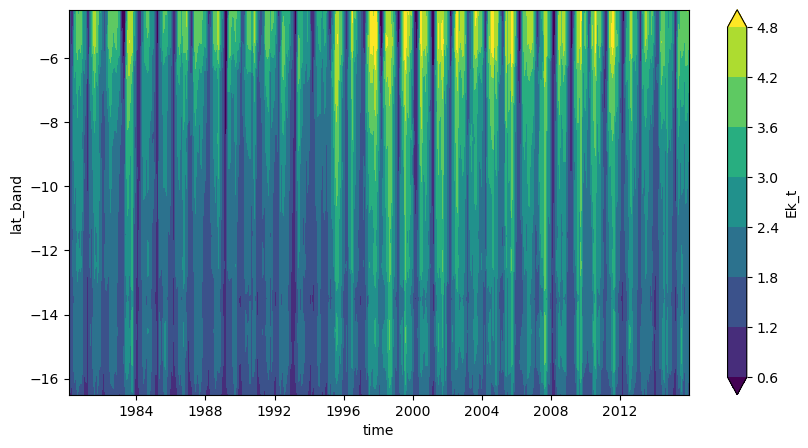

In [11]:
lat_band_mean_(Ek_t).sel(lat_band=slice(lati1,lati2)).plot.contourf(robust=True,figsize=(10,5))
Ek_t = lat_band_mean_(Ek_t)
Ek_t

In [12]:
### 250 km
coast_lons, offshore_lons = get_boundary_lons(
    wind_coastal, 
    var='Uek_geo', 
    target_width_km=250,
    lon_slice=slice(-85, None), 
    lat_slice=slice(lati2, lati1)
)

Text(0.5, 1.0, 'coast / offshore boundary detection')

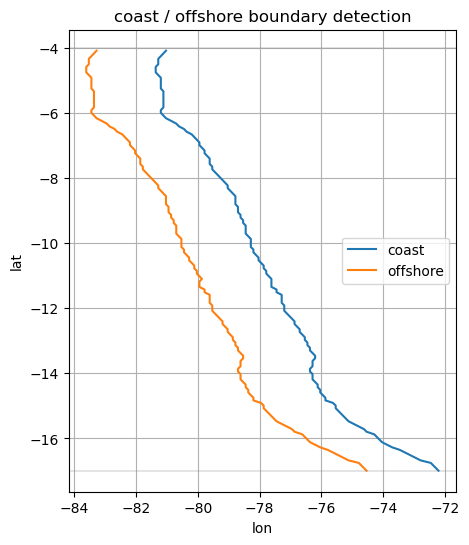

In [13]:
# Coastline diagnostic — verify coast_lons/offshore_lons look smooth.
# Jumps in coast_lons (from islands, bays, masked pixels) were the
# cause of the earlier inflated d_coast in bands 2, 11, 12.
fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(coast_lons, wind_coastal.lat, label='coast')
ax.plot(offshore_lons, wind_coastal.lat, label='offshore')
ax.set_xlabel('lon'); ax.set_ylabel('lat')
ax.axhline(-4,  color='grey', lw=0.3)
ax.axhline(-17, color='grey', lw=0.3)
ax.legend(); ax.grid(True)
ax.set_title('coast / offshore boundary detection')

In [14]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000.0
    lat1_rad = np.deg2rad(lat1)
    lon1_rad = np.deg2rad(lon1)
    lat2_rad = np.deg2rad(lat2)
    lon2_rad = np.deg2rad(lon2)
    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad
    a = (np.sin(delta_lat / 2.0) ** 2
         + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(delta_lon / 2.0) ** 2)
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

In [15]:
# ============================================================
# 4. qdiv function — returns m²/s
# ============================================================
def coast_path_length(lat_south, lat_north, all_lats, coast_lons):
    """Cumulative along-coast distance by summing haversine between
    consecutive coastal cells inside the band. Robust to coastline
    curvature and endpoint noise."""
    band_idx = np.where((all_lats >= lat_south) & (all_lats <= lat_north))[0]
    pts = [(all_lats[j], coast_lons[j]) for j in band_idx
           if np.isfinite(coast_lons[j])]
    if len(pts) < 2:
        return np.nan
    d = 0.0
    for (la1, lo1), (la2, lo2) in zip(pts[:-1], pts[1:]):
        d += haversine(la1, lo1, la2, lo2)
    return d


def qdiv_for_band(Uek, Vek,
                  lat_south, lat_north,
                  offshore_lons, coast_lons, all_lats):

    A = 6371000.0

    Uek_ = Uek.sel(lat=slice(lat_south, lat_north))
    Vek_ = Vek.sel(lat=slice(lat_south, lat_north))

    lat_vals = Uek_.lat.values
    lon_vals = Uek_.lon.values
    mean_lat = np.mean(lat_vals)

    # Cumulative along-coast length (sums all intermediate coastal cells
    # rather than just the band endpoints — avoids spurious inflation
    # when coastline bends or endpoint detection is noisy).
    d_coastline = coast_path_length(lat_south, lat_north, all_lats, coast_lons) # distance of the coastline between latitudes

    # Build 2D strip mask following coast/offshore boundaries per row
    band_idx = np.where((all_lats >= lat_south) & (all_lats <= lat_north))[0]
    strip_mask = np.zeros((len(lat_vals), len(lon_vals)), dtype=bool)

    for j, idx in enumerate(band_idx):
        if j >= len(lat_vals):
            break
        lw = offshore_lons[idx]
        le = coast_lons[idx]
        if np.isfinite(lw) and np.isfinite(le):
            strip_mask[j, :] = (lon_vals >= lw) & (lon_vals <= le)

    # Apply strip mask
    strip_da = xr.DataArray(strip_mask, dims=('lat', 'lon'),
                            coords={'lat': lat_vals, 'lon': lon_vals})
    Uek_ = Uek_.where(strip_da)
    Vek_ = Vek_.where(strip_da)

    # Grid spacing for face integration
    dy_mean = A * np.deg2rad(np.abs(np.diff(lat_vals))).mean()
    dx_mean = A * np.cos(np.deg2rad(mean_lat)) * np.deg2rad(np.abs(np.diff(lon_vals))).mean()

    # Boundary detection
    valid_da = xr.where(np.isfinite(Uek_), 1, 0)
    valid_e = valid_da.shift(lon=-1)
    valid_w = valid_da.shift(lon=+1)
    west_mask = (valid_da == 1) & (valid_w == 0)
    east_mask = (valid_da == 1) & (valid_e == 0)

    easternmost_u  = Uek_.where(east_mask)    
    westernmost_u  = Uek_.where(west_mask)
 
    easternmost_v = Vek_.where(east_mask)
    westernmost_v = Vek_.where(west_mask)
    
    southernmost = Vek_.isel(lat=0)
    northernmost = Vek_.isel(lat=-1)

    # Volume fluxes through each face (m³/s)
    QE = (easternmost_u.mean('lon')
          .rolling(lat=2, center=False)
          .mean(skipna=True).sum(dim='lat') * dy_mean)
    
    QW_u = -(westernmost_u.mean('lon')
           .rolling(lat=2, center=False)
           .mean(skipna=True).sum(dim='lat') * dy_mean) 
    
    QW_v = - (westernmost_v.mean('lon')
           .rolling(lat=2, center=False)
           .mean(skipna=True).sum(dim='lat') * dy_mean) 

    QN = (northernmost
          .rolling(lon=2, center=False)
          .mean(skipna=True).sum(dim='lon') * dx_mean)
    QS = -(southernmost
           .rolling(lon=2, center=False)
           .mean(skipna=True).sum(dim='lon') * dx_mean)

    #Cross-shore
    L_zonal = A * np.cos(np.deg2rad(mean_lat)) * np.deg2rad(np.abs(coast_lons[j] - offshore_lons[j]))
    
    # Normalize by alongshore length → m²/s
    Qdiv = (QW_u/d_coastline + QW_v/d_coastline + QS/d_coastline + QN/d_coastline)

    return Qdiv,d_coastline,QW_u/d_coastline,QW_v/d_coastline,QS/d_coastline,QN/d_coastline, QE/d_coastline

In [16]:
# ============================================================
# 5. Loop over latitude bands
# ============================================================
# Qdiv,d_coast,QW,QS,QN
lat_top_start = -4
lat_top_end   = -17
lat_all = wind_coastal.lat.values

results = []
lat_band_centers = []
d_coastline = []
QW_u = []
QW_v = []
QS_ = []
QN_ = []
QE_ = []

for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
    lat_south = lat_north - 1
    Qdiv_band,dd,QWu,QWv,QS,QN,QE = qdiv_for_band(
        wind_coastal.Uek_geo, wind_coastal.Vek_geo,
        lat_south=lat_south, lat_north=lat_north,
        offshore_lons=offshore_lons.values, coast_lons=coast_lons.values,
        all_lats=lat_all,
    )
    results.append(Qdiv_band)
    lat_band_centers.append(0.5 * (lat_south + lat_north))
    d_coastline.append(dd)
    QW_u.append(QWu)
    QW_v.append(QWv)
    QS_.append(QS)
    QN_.append(QN)
    QE_.append(QE)

Qdiv_all = xr.concat(results, dim='lat_band')
QW_u_all = xr.concat(QW_u, dim='lat_band')
QW_v_all = xr.concat(QW_v, dim='lat_band')
QS_all = xr.concat(QS_, dim='lat_band')
QN_all = xr.concat(QN_, dim='lat_band')
QE_all = xr.concat(QE_, dim='lat_band')

U_ek_ = Qdiv_all.assign_coords(lat_band=lat_band_centers)
QW__u = QW_u_all.assign_coords(lat_band=lat_band_centers) 
QW__v = QW_v_all.assign_coords(lat_band=lat_band_centers) 

QS__ = QS_all.assign_coords(lat_band=lat_band_centers)
QN__ = QN_all.assign_coords(lat_band=lat_band_centers)
QE__ = QE_all.assign_coords(lat_band=lat_band_centers)

100%|█████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 25.76it/s]


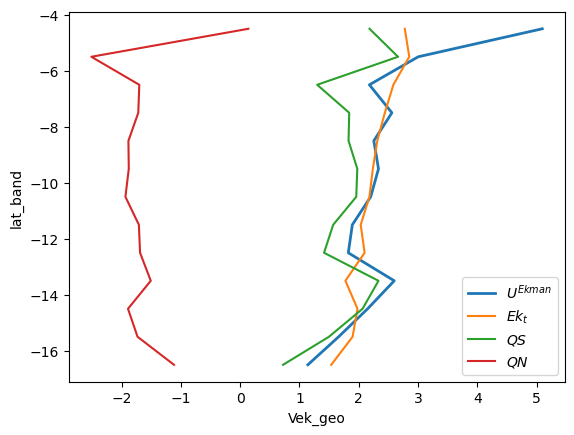

In [17]:
U_ek   = (Ek_t + QS__ + QN__)

U_ek.mean('time').plot(y='lat_band',label='$U^{Ekman}$',linewidth=2)
Ek_t.mean('time').plot(y='lat_band',label='$Ek_t$')
QS__.mean('time').plot(y='lat_band',label='$QS$')
QN__.mean('time').plot(y='lat_band',label='$QN$')

plt.legend()

In [18]:
# This should show ~100 km difference per row
for j in range(len(lat_all)):
    if np.isfinite(coast_lons[j]) and np.isfinite(offshore_lons[j]):
        diff = np.abs(coast_lons[j] - offshore_lons[j])
        # if diff > 1.5:  # more than ~1.5 degrees = ~150 km
        print(f"lat={lat_all[j]:.1f}: coast={coast_lons[j]:.2f}, offshore={offshore_lons[j]:.2f}, diff={diff:.2f}°")

lat=-17.0: coast=-72.20, offshore=-74.53, diff=2.33°
lat=-16.9: coast=-72.28, offshore=-74.62, diff=2.33°
lat=-16.8: coast=-72.37, offshore=-74.70, diff=2.33°
lat=-16.8: coast=-72.45, offshore=-74.78, diff=2.33°
lat=-16.7: coast=-72.78, offshore=-75.12, diff=2.33°
lat=-16.6: coast=-72.95, offshore=-75.28, diff=2.33°
lat=-16.5: coast=-73.12, offshore=-75.45, diff=2.33°
lat=-16.4: coast=-73.28, offshore=-75.62, diff=2.33°
lat=-16.4: coast=-73.45, offshore=-75.78, diff=2.33°
lat=-16.3: coast=-73.70, offshore=-76.03, diff=2.33°
lat=-16.2: coast=-73.87, offshore=-76.20, diff=2.33°
lat=-16.1: coast=-74.03, offshore=-76.37, diff=2.33°
lat=-16.0: coast=-74.12, offshore=-76.45, diff=2.33°
lat=-16.0: coast=-74.20, offshore=-76.53, diff=2.33°
lat=-15.9: coast=-74.28, offshore=-76.62, diff=2.33°
lat=-15.8: coast=-74.53, offshore=-76.87, diff=2.33°
lat=-15.7: coast=-74.62, offshore=-76.95, diff=2.33°
lat=-15.6: coast=-74.78, offshore=-77.12, diff=2.33°
lat=-15.6: coast=-74.95, offshore=-77.28, diff

In [19]:
widths = []
A = 6371000.0
for j in range(len(lat_all)):
    if np.isfinite(coast_lons[j]) and np.isfinite(offshore_lons[j]):
        w = A * np.cos(np.deg2rad(lat_all[j])) * np.deg2rad(np.abs(coast_lons[j] - offshore_lons[j]))
        widths.append(w)
d_band = np.mean(widths)
print(f"Mean cross-shore width: {d_band/1000:.1f} km")

Mean cross-shore width: 249.5 km


In [20]:
A = 6371000.0
widths = np.full(len(lat_all), np.nan)
for j in range(len(lat_all)):
    if np.isfinite(coast_lons[j]) and np.isfinite(offshore_lons[j]):
        widths[j] = A * np.cos(np.deg2rad(lat_all[j])) * np.deg2rad(np.abs(coast_lons[j] - offshore_lons[j]))

widths_da = xr.DataArray(widths, dims='lat', coords={'lat': lat_all}, name='cross_shore_width')

d = lat_band_mean_(widths_da, lat_top_start=-4, lat_top_end=-17) #cross-shore distance
print(d) # L length from the coast to the offshore

100%|███████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 4626.72it/s]

<xarray.DataArray 'cross_shore_width' (lat_band: 13)> Size: 104B
array([249401.76935861, 249020.12839815, 248564.07008193, 248034.28216051,
       247431.55927156, 246756.80006215, 246011.00396191, 252840.12970039,
       253279.71412002, 252286.73078933, 251179.14128749, 249999.96707891,
       248749.09134001])
Coordinates:
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5


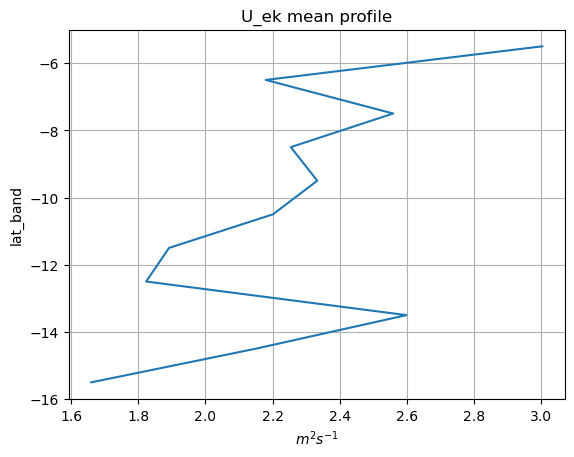

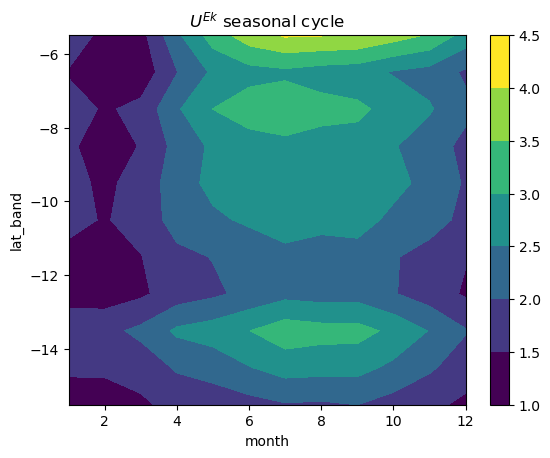

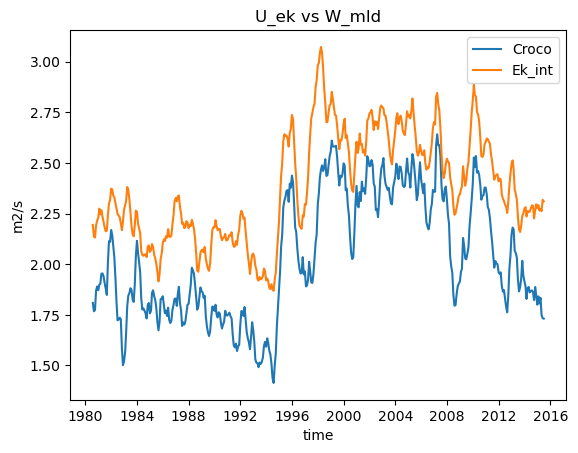

In [21]:
# ============================================================
# 6. Quick checks
# ============================================================

# Seasonality
def seasonality(data):
    return data.groupby('time.month').mean(dim='time')

# Latitudinal mean profile
U_ek.sel(lat_band=slice(-5, -16)).mean('time').rename('$m^{2}s^{-1}$').plot(y='lat_band')
plt.title('U_ek mean profile')
plt.grid(True)
plt.show()

# Seasonal Hovmöller
seasonality(U_ek).sel(lat_band=slice(-5, -16)).plot.contourf(x='month')
plt.title('$U^{Ek}$ seasonal cycle')
plt.show()

# Time series comparison with W_mld
wmld = xr.open_dataset('../W_mld_Croco.nc').compute()
wmld = wmld.where(mask).sel(lon=slice(-85, None), lat=slice(-16, -5))


(wmld*mask_km*1000).mean(dim=('lon', 'lat')).WMLD.rolling(time=13, center=True).mean().rename('m/s').plot(label='Croco')
(U_ek).mean(dim='lat_band').rolling(time=13, center=True).mean().rename('m2/s').plot(label='Ek_int')
plt.legend()
plt.title('U_ek vs W_mld')
plt.show()

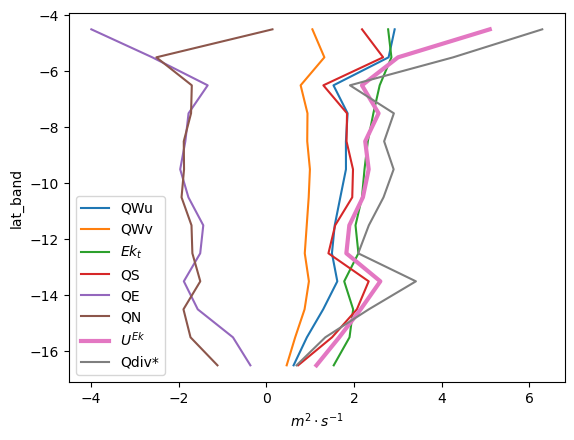

In [22]:
QW__u.mean('time').plot(y='lat_band',label='QWu')
QW__v.mean('time').plot(y='lat_band',label='QWv')

Ek_t.mean('time').plot(y='lat_band',label='$Ek_t$')
(QS__).mean('time').plot(y='lat_band',label='QS')
QE__.mean('time').plot(y='lat_band',label='QE')
QN__.mean('time').rename('$m^2 \cdot s^{-1}$').plot(y='lat_band',label='QN')
U_ek.mean('time').rename('$m^2 \cdot s^{-1}$').plot(y='lat_band',label='$U^{Ek}$',linewidth=3)
(QW__u + QW__v + QS__ + QN__).mean('time').rename('$m^2 \cdot s^{-1}$').plot(y='lat_band',label='Qdiv*')
plt.legend()

## Now the Geostrophic Velocity

$
u_{\mathrm{geo}} = \frac{g}{f}\,\frac{\Delta \mathrm{SSH}}{d_{\mathrm{coast}}}
$

$
\mathbf{U}_{\mathrm{geo}} = \mathbf{u}_{\mathrm{geo}} \times \mathrm{MLD}
$

In [23]:
ssh = xr.open_dataset('../SSH.nc').compute()
ssh

<xarray.Dataset> Size: 564MB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
Data variables:
    SSH      (time, lat, lon) float32 564MB 0.212 0.212 0.2117 ... 0.0 0.0 0.0

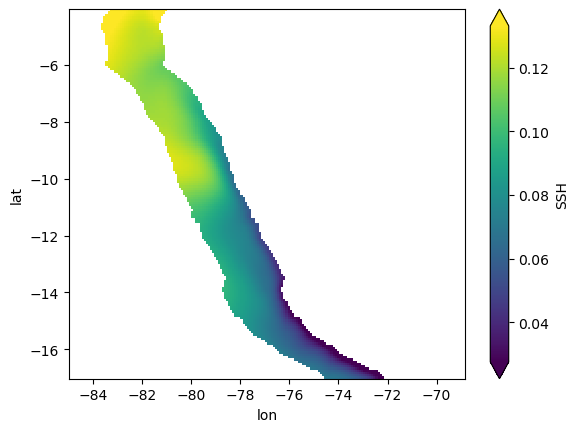

In [24]:
## SSH is in m
ssh = ssh.where(mask).sel(lon=slice(-85,None),lat=slice(lati2,lati1))
ssh.mean('time').SSH.plot(robust=True)

In [25]:
valid = np.isfinite(ssh.SSH.isel(time=0))
valid_e = valid.shift(lon=-1).fillna(False).astype(bool)
coast_mask = valid & (~valid_e)
ssh_coast = ssh.SSH.where(coast_mask)

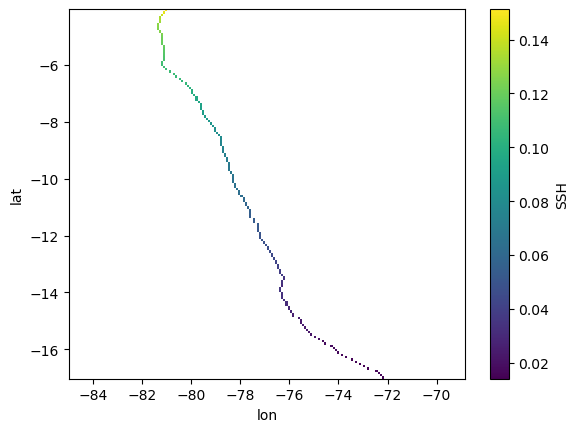

In [26]:
ssh_coast.mean('time').plot()

In [27]:
lat_centers = np.arange(lat_top_start - 0.5, lat_top_end - 0.5, -1)
Omega = 7.2921e-5
f_ = 2 * Omega * np.sin(np.deg2rad(lat_centers))
f_ = xr.DataArray(f_, dims='lat_band', coords={'lat_band': lat_centers})
f_

<xarray.DataArray (lat_band: 13)> Size: 104B
array([-1.14426314e-05, -1.39783362e-05, -1.65097831e-05, -1.90362009e-05,
       -2.15568201e-05, -2.40708729e-05, -2.65775935e-05, -2.90762183e-05,
       -3.15659862e-05, -3.40461388e-05, -3.65159206e-05, -3.89745792e-05,
       -4.14213659e-05])
Coordinates:
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5

In [28]:
lat_top_start = -4
lat_top_end   = -17

delta_SSH = []
d_coast_list = []

for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
    lat_south = lat_north - 1
    SSH_band = ssh_coast.mean('lon').sel(lat=slice(lat_south, lat_north))

    southernmost = SSH_band.isel(lat=0)
    northernmost = SSH_band.isel(lat=-1)
    delta_SSH.append(northernmost - southernmost)

    # Cumulative along-coast distance (robust to coast curvature)
    d_ = coast_path_length(lat_south, lat_north, lat_all, coast_lons)
    d_coast_list.append(d_)

ssh_ = xr.concat(delta_SSH, dim='lat_band')
ssh_ = ssh_.assign_coords(
    lat_band=np.arange(lat_top_start - 0.5, lat_top_end - 0.5, -1)
)

d_coast_ = xr.DataArray(d_coast_list, dims='lat_band',
                        coords={'lat_band': ssh_.lat_band})

# Sanity check: expect ~111 km plus a small curvature increment
for i, dc in enumerate(d_coast_list):
    lat_only = 6371000 * np.deg2rad(1.0)  # ~111 km
    print(f"Band {i}: d_coast = {dc/1000:.1f} km (vs {lat_only/1000:.1f} km lat-only, {(dc/lat_only-1)*100:+.1f}%)")

# Verify: should be positive on average (SSH increases northward along coast)
print("Mean ssh_ (should be positive):", ssh_.mean().values)

100%|█████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 20.53it/s]


Band 0: d_coast = 124.6 km (vs 111.2 km lat-only, +12.0%)
Band 1: d_coast = 109.1 km (vs 111.2 km lat-only, -1.9%)
Band 2: d_coast = 169.7 km (vs 111.2 km lat-only, +52.6%)
Band 3: d_coast = 127.7 km (vs 111.2 km lat-only, +14.8%)
Band 4: d_coast = 123.6 km (vs 111.2 km lat-only, +11.1%)
Band 5: d_coast = 119.4 km (vs 111.2 km lat-only, +7.4%)
Band 6: d_coast = 122.9 km (vs 111.2 km lat-only, +10.5%)
Band 7: d_coast = 138.9 km (vs 111.2 km lat-only, +24.9%)
Band 8: d_coast = 129.5 km (vs 111.2 km lat-only, +16.4%)
Band 9: d_coast = 117.8 km (vs 111.2 km lat-only, +5.9%)
Band 10: d_coast = 149.3 km (vs 111.2 km lat-only, +34.3%)
Band 11: d_coast = 176.5 km (vs 111.2 km lat-only, +58.7%)
Band 12: d_coast = 234.2 km (vs 111.2 km lat-only, +110.6%)
Mean ssh_ (should be positive): 0.009845316


In [29]:
print(d)
print(d_coastline)

<xarray.DataArray 'cross_shore_width' (lat_band: 13)> Size: 104B
array([249401.76935861, 249020.12839815, 248564.07008193, 248034.28216051,
       247431.55927156, 246756.80006215, 246011.00396191, 252840.12970039,
       253279.71412002, 252286.73078933, 251179.14128749, 249999.96707891,
       248749.09134001])
Coordinates:
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5
[124562.36726699636, 109086.10661761712, 169670.87512256543, 127677.24756541123, 123578.50321153678, 119449.85148189467, 122860.52938317883, 138919.86100024404, 129472.51415582518, 117761.6441584467, 149288.70425897668, 176473.69088798173, 234172.44696987938]


In [30]:
# dy = 250*1000 # 1 degree of latitude in meters
g = 9.81

# Geostrophic cross-shore velocity from alongshore SSH gradient at the coast.
# u_geo = (g/f) * (dSSH/dy)
# Sign convention for CUTI divergence framework:
#   In SH (f<0), with SSH increasing northward (ssh_>0):
#     u_geo = (g / f_neg) * (positive) = negative → onshore (convergent)
#   This is correct: onshore geostrophic return flow reduces CUTI below U_ek.
# u_geo = (g / f_) * (ssh_ )
u_geo = (g / f_) * (ssh_ / d_coast_)

# Verify: should be negative on average (onshore)
print("Mean u_geo (should be negative):", u_geo.mean().values)

Mean u_geo (should be negative): -0.04074680118604648


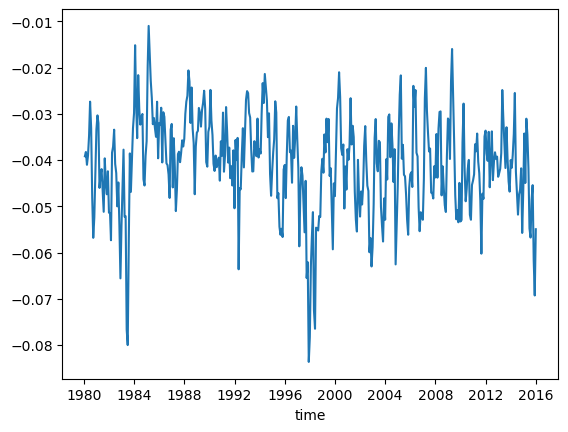

In [31]:
u_geo.mean(dim=('lat_band')).plot()

* The onshore geostrophic flow increased during EN 1997-98

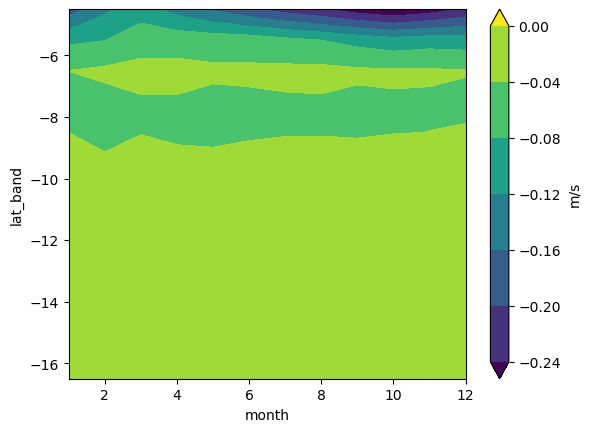

In [32]:
seasonality(u_geo.rename('m/s')).plot.contourf(robust=True)

### MLD

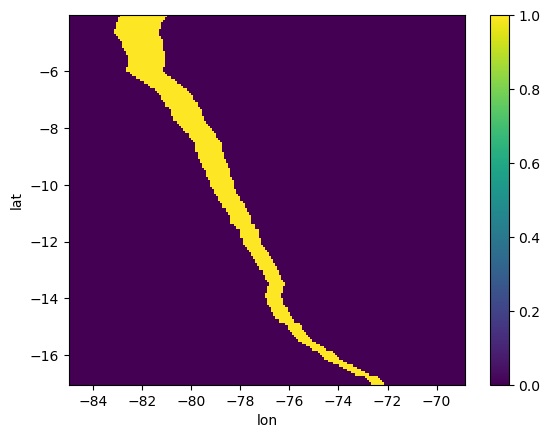

In [33]:
R_X = xr.open_dataset('../Rossby_radius_and_X.nc').compute()
mask = coastal_band_mask(R_X, var='R', target_width_km=mask_km)
R_X = R_X.where(mask).sel(lon=slice(-85,None),lat=slice(lati2,lati1)) 
R_lati = (R_X/1000).R.mean('lon')

mask_rossby = coastal_band_mask_rossby(R_X, var='R', R1=R_lati)
mask_rossby.plot()

In [34]:
MLD_ds = xr.open_dataset('../MLD.nc').compute()
MLD_ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 1GB 0.9402 0.9402 1.335 ... nan nan nan

In [35]:
mask_mld = coastal_band_mask(MLD_ds, var='MLD', target_width_km=20) #93.79029711 km
MLD_ds = MLD_ds.where(mask_mld).sel(lon=slice(-85,None),lat=slice(-20,-4))
MLD_ds

<xarray.Dataset> Size: 132MB
Dimensions:  (time: 432, lat: 197, lon: 194)
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 2kB -19.99 -19.92 -19.84 ... -4.245 -4.162 -4.079
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 132MB nan nan nan nan ... nan nan nan nan

* Rossby radious in Peru goes from 150 to 50km, then the MLD should be around 100km, following first deformation Rossby radious criteria by Jacox(2018)

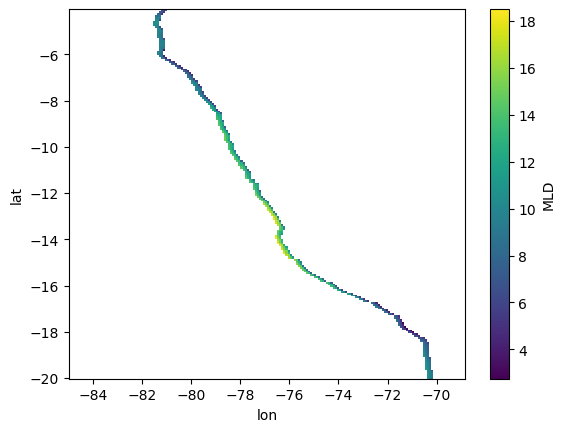

In [36]:
MLD_ds.MLD.std('time').plot()

100%|████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 146.93it/s]


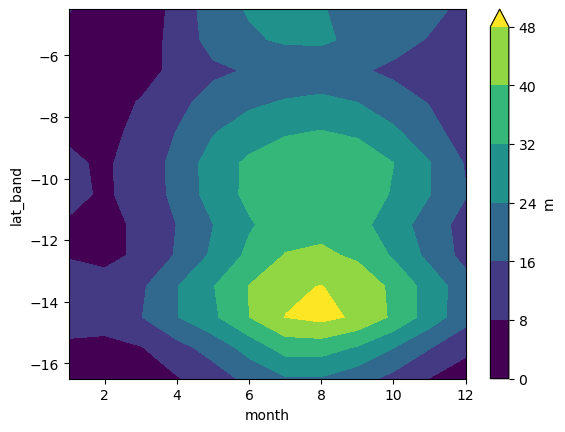

In [37]:
mld_ = lat_band_mean(MLD_ds.MLD)
# mld_
seasonality(mld_).rename('m').plot.contourf(x='month',robust=True)

## $U^{geo}$

Text(0.5, 1.0, '$U^{Geo}$')

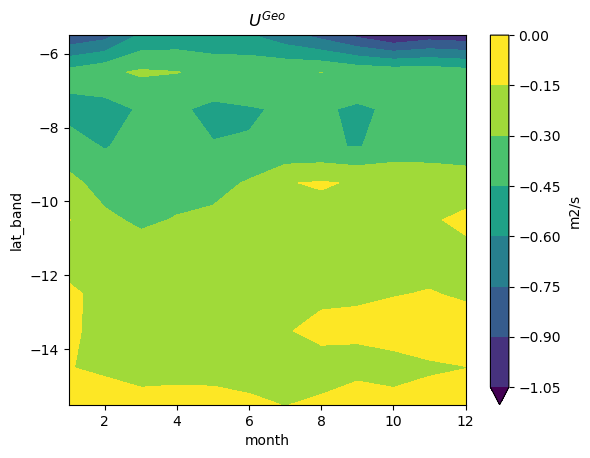

In [90]:
U_geo = (u_geo * 10)
seasonality((u_geo * 10)).sel(lat_band=slice(-5,-16)).rename('m2/s').plot.contourf(robust=True)
# seasonality((u_geo * mld_).mean(dim='lon')).rename('m2/s').plot.contourf(robust=True)

plt.title('$U^{Geo}$')

* Negative is onshore 

In [91]:
U_geo.sel(lat_band=slice(-5.5,-16.5))

<xarray.DataArray (lat_band: 12, time: 432)> Size: 41kB
array([[-1.06774395, -0.80165278, -0.58148042, ..., -1.50955158,
        -1.09865496, -1.1390308 ],
       [-0.43120598, -0.35708669, -0.45370762, ..., -0.60553753,
        -1.05442383, -0.53047761],
       [-0.29100726, -0.52183372, -0.59770921, ..., -0.56631744,
        -0.76115047, -0.54095514],
       ...,
       [-0.10921159, -0.1942356 , -0.1920741 , ..., -0.30134482,
        -0.31271135, -0.33172891],
       [-0.00693513, -0.05376634, -0.05520243, ..., -0.10373595,
        -0.04848461, -0.03539041],
       [-0.01369521,  0.06195866, -0.02640548, ..., -0.003271  ,
        -0.1297217 , -0.03755911]])
Coordinates:
  * lat_band  (lat_band) float64 96B -5.5 -6.5 -7.5 -8.5 ... -14.5 -15.5 -16.5
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

## CUTI

$CUTI$ = $U^{Ek}$ + $U^{Geo}$

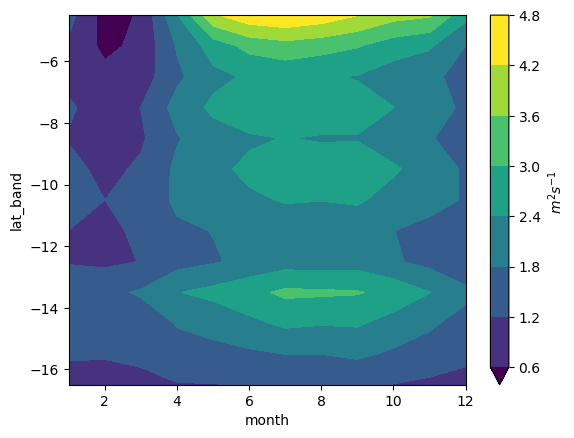

In [92]:
CUTI = (U_ek) + (U_geo)#m2/s

seasonality((CUTI)).sel(lat_band=slice(lati1,lati2)).rename('$m^2s^{-1}$').plot.contourf(robust=True)

Text(0.5, 1.0, '$CUTI$')

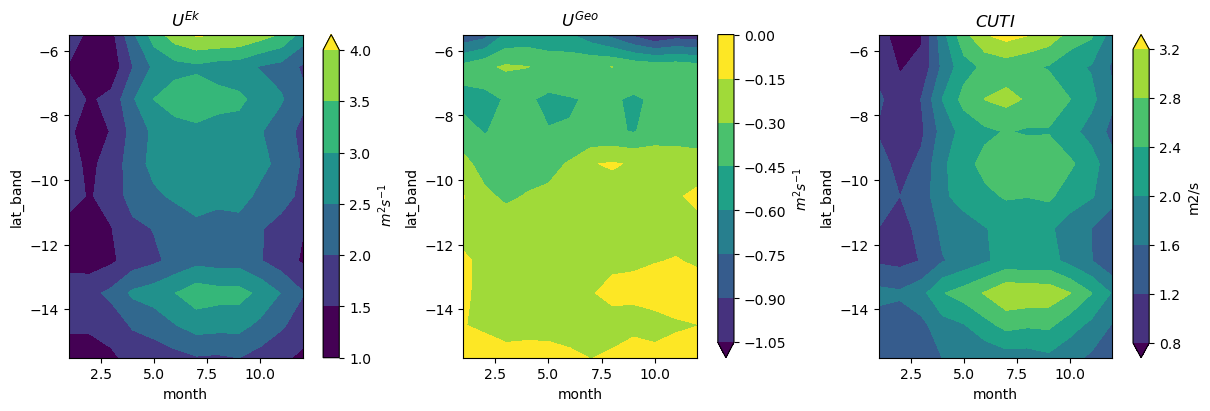

In [93]:
fig,ax = plt.subplots(1,3,figsize=(12,4),constrained_layout=True)

seasonality(U_ek).sel(lat_band=slice(-5,-16)).rename('$m^2s^{-1}$').plot.contourf(
    x='month',robust=True,ax=ax[0])
seasonality(U_geo).sel(lat_band=slice(-5,-16)).rename('$m^2s^{-1}$').plot.contourf(
    x='month',robust=True,ax=ax[1])
seasonality(CUTI).sel(lat_band=slice(-5,-16)).rename('m2/s').plot.contourf(
    x='month',robust=True,ax=ax[2])

ax[0].set_title('$U^{Ek}$')
ax[1].set_title('$U^{Geo}$')
ax[2].set_title('$CUTI$')

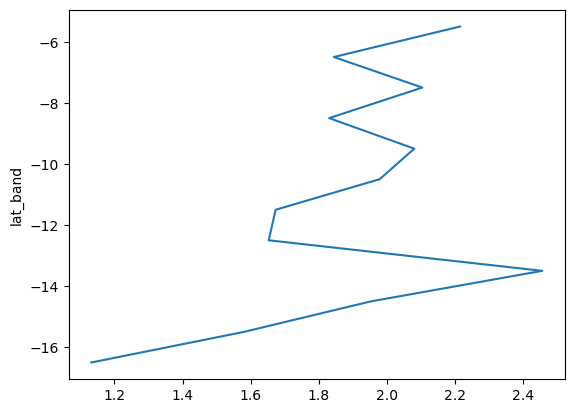

In [94]:
(CUTI).mean('time').sel(lat_band=slice(-5,-16.5)).plot(y='lat_band')

# (CUTI/d).mean(dim=('lon','time')).plot(y='lat_band')

In [95]:
wmld2 = xr.open_dataset('../W_mld_Croco.nc').compute()
wmld2 = wmld2.where(mask).sel(lon=slice(-85,None),lat=slice(lati2,lati1))
wmld2

<xarray.Dataset> Size: 107MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Data variables:
    WMLD     (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

In [96]:
wmld__ = transport_band(wmld2.fillna(0).WMLD,
    lat_top_start=-4,
    lat_top_end=-17,
)

100%|████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 110.96it/s]


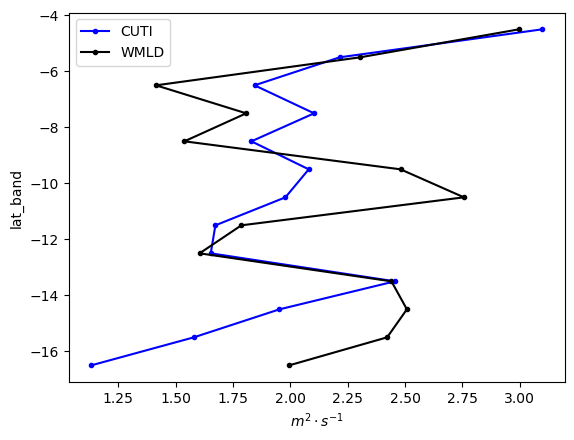

In [97]:
R = 6371000.0
# convert degree spacing to radians
dlon = np.deg2rad(1/12)
# latitude in radians (2D or 1D broadcastable)
lat_rad = np.deg2rad(wmld['lat'])
# dx (meters), varies with latitude
dx = R * np.cos(lat_rad) * dlon

##### 
# (wmld2.fillna(0) * dx).sum(dim='lon').mean('time').WMLD.rolling(lat=13,center=True).mean().plot(y='lat',color='gray')
CUTI.mean(dim=('time')).plot(y='lat_band',label='CUTI',color='blue',marker='.')
wmld__.mean(dim=('time')).rename('$m^{2} \cdot s^{-1}$').plot(y='lat_band',label='WMLD',color='black',marker='.')
plt.legend()

In [98]:
wmld_ = lat_band_mean(wmld2.WMLD,
    lat_top_start=-4,
    lat_top_end=-17,
)

100%|████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 144.98it/s]


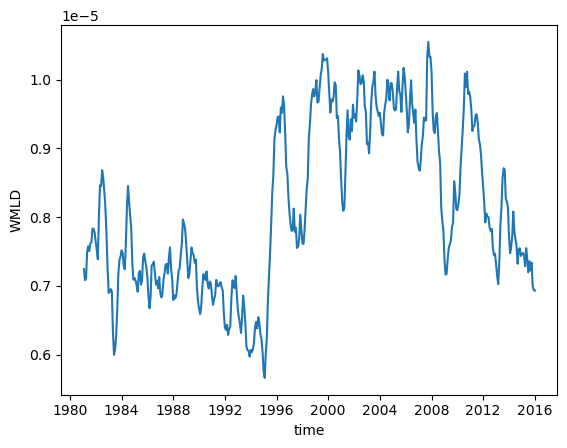

In [99]:
wmld_.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).rolling(time=13).mean().plot()

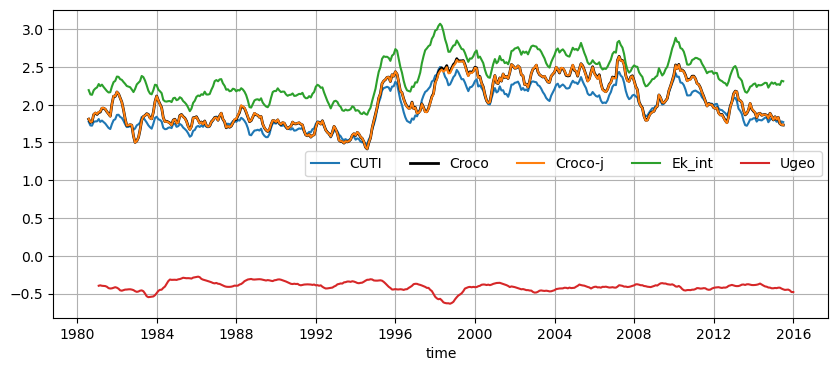

In [100]:
(CUTI).sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).rolling(time=13,center=True).mean().plot(label='CUTI',figsize=(10,4))
(wmld*250*1000).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).WMLD.rolling(time=13,center=True).mean().rename('m/s').plot(label='Croco',linewidth=2,color='black')
(wmld_*250*1000).sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).rolling(time=13,center=True).mean().rename('m/s').plot(label='Croco-j')

(((U_ek)).mean(dim='lat_band')).rolling(time=13,center=True).mean().rename('m/s').plot(label='Ek_int')
(U_geo).mean(dim=('lat_band')).rolling(time=13).mean().plot(label='Ugeo')

plt.legend(ncols=6,loc='best')
plt.grid()

### Seasonality

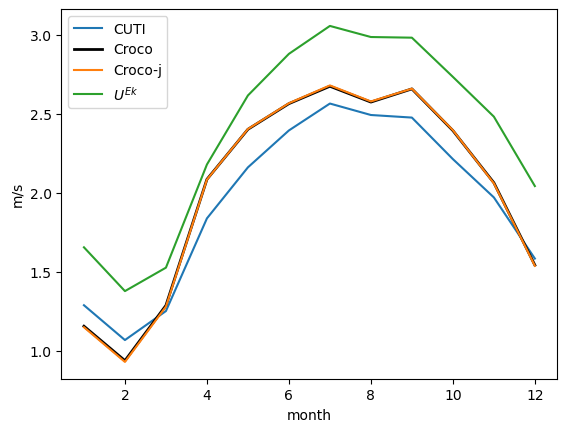

In [101]:
seasonality((CUTI)).sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).plot(label='CUTI')
seasonality(wmld*250*1000).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).WMLD.rename('m/s').plot(label='Croco',linewidth=2,color='black')
seasonality(wmld_*250*1000).sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).rename('m/s').plot(label='Croco-j')

(seasonality(U_ek)).mean(dim='lat_band').rename('m/s').plot(label='$U^{Ek}$')
# seasonality((U_geo/d).mean(dim=('lat_band','lon'))).plot(label='$U^{Geo}$')
# seasonality((ds.Uekman_Crossshore*-1/d).mean(dim=('lon','lat'))).plot(label='Uekman_crosshore')

plt.legend()

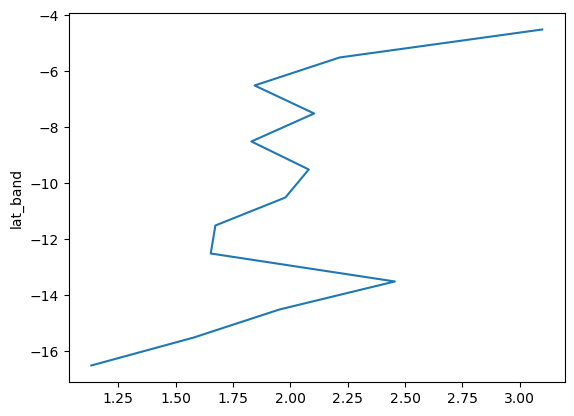

In [102]:
# (wmld*60*60*24).mean('time').WMLD.plot.contourf(robust=True,vmin=-5, vmax=5, cmap='RdBu_r',levels)
(CUTI).mean('time').plot(y='lat_band')

In [103]:
nitrogen = xr.open_dataset('../Nitrogen.nc').compute()
nitrogen

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    TN_surf  (time, lat, lon) float32 564MB 0.1585 0.1588 0.1642 ... 0.0 0.0 0.0
    TN_mld   (time, lat, lon) float64 1GB 0.1585 0.1588 0.1642 ... 0.0 0.0 0.0

In [104]:
N = nitrogen.where(mask_mld).sel(lon=slice(-85,None),lat=slice(lati2,lati1))
N

<xarray.Dataset> Size: 160MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    TN_surf  (time, lat, lon) float32 53MB nan nan nan nan ... nan nan nan nan
    TN_mld   (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

In [105]:
N_ = lat_band_mean(N.TN_mld,
    lat_top_start=-4,
    lat_top_end=-17,
)
N_

100%|████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 151.53it/s]


<xarray.DataArray 'TN_mld' (lat_band: 13, time: 432)> Size: 45kB
array([[ 9.98154336,  7.64120445,  7.70262567, ..., 10.80847328,
         8.3792168 , 10.63325774],
       [12.2069356 ,  9.05870825,  9.57555243, ..., 14.92500753,
        11.89335261, 13.441394  ],
       [12.75852314, 10.66986426, 10.23042578, ..., 17.38428869,
        15.43433039, 15.68088845],
       ...,
       [10.94088296, 15.99201344, 12.47512196, ..., 18.46291329,
        19.25964129, 19.09433343],
       [10.44705728,  9.50880416,  9.9066697 , ..., 16.58690805,
        13.84847719, 12.86137422],
       [ 5.16806986,  6.14645234,  5.08191954, ..., 13.90192083,
        10.89643879,  7.50551488]])
Coordinates:
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5

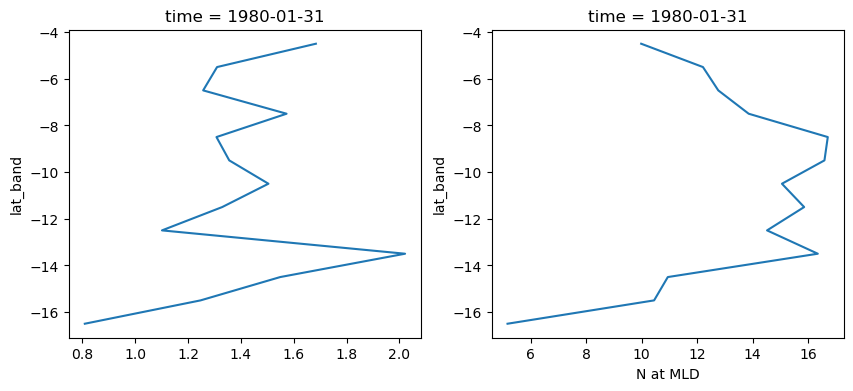

In [106]:
fig,ax = plt.subplots(1,2,figsize=(10,4))
CUTI.isel(time=0).plot(ax=ax[0],y='lat_band')
N_.rename('N at MLD').isel(time=0).plot(ax=ax[1],y='lat_band')

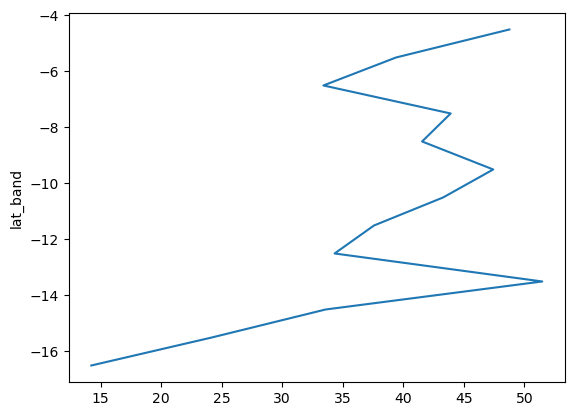

In [107]:
BEUTI = (N_ * CUTI)
(BEUTI).mean('time').plot(y='lat_band')

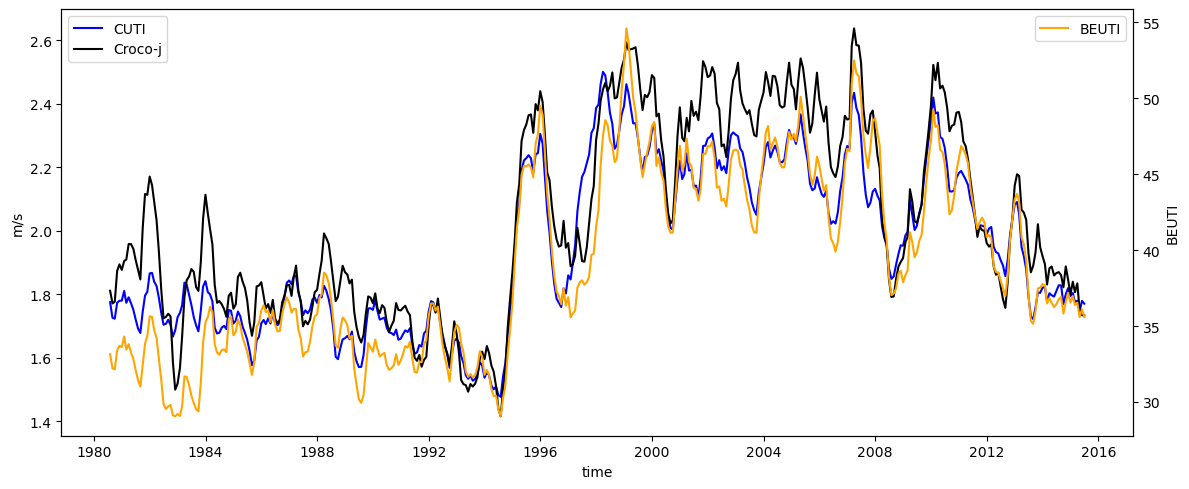

In [108]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Left axis
(CUTI).sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).rolling(time=13,center=True).mean().plot(ax=ax1, label='CUTI', color='Blue')
# (CUTI/d).sel(lat_band=slice(-5,-16)).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(label='CUTI')

# (wmld*250*1000).mean(dim=('lon','lat')).WMLD.rolling(time=13,center=True).mean().rename('m/s').plot(ax=ax1, label='Croco', linewidth=2, color='black')
(wmld_*250*1000).sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).rolling(time=13,center=True).mean().rename('m/s').plot(ax=ax1, label='Croco-j',color='black')
ax1.set_ylabel('m/s')
ax1.legend(loc='upper left')

# Right axis for BEUTI
ax2 = ax1.twinx()
BEUTI.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).rolling(time=13,center=True).mean().plot(ax=ax2, label='BEUTI', color='orange')
ax2.set_ylabel('BEUTI')
ax2.legend(loc='upper right')

plt.tight_layout()

In [109]:
N2 = nitrogen.where(mask_mld).sel(lon=slice(-85,None),lat=slice(-16,-5))

Text(0.5, 1.0, 'Nitrogen Cycle')

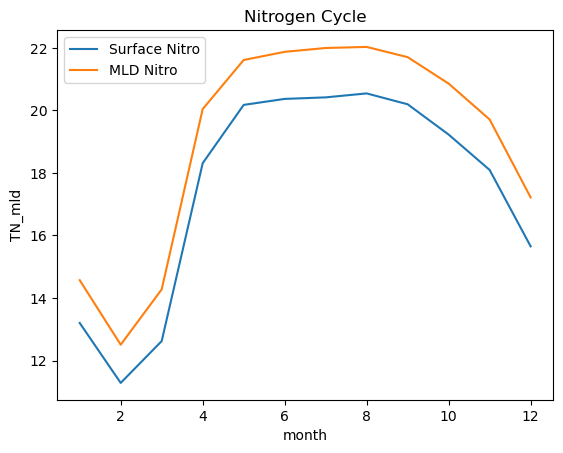

In [110]:
seasonality(N2.TN_surf).mean(dim=('lat','lon')).plot(label='Surface Nitro')
seasonality(N2.TN_mld).mean(dim=('lat','lon')).plot(label='MLD Nitro')
plt.legend()
plt.title('Nitrogen Cycle')

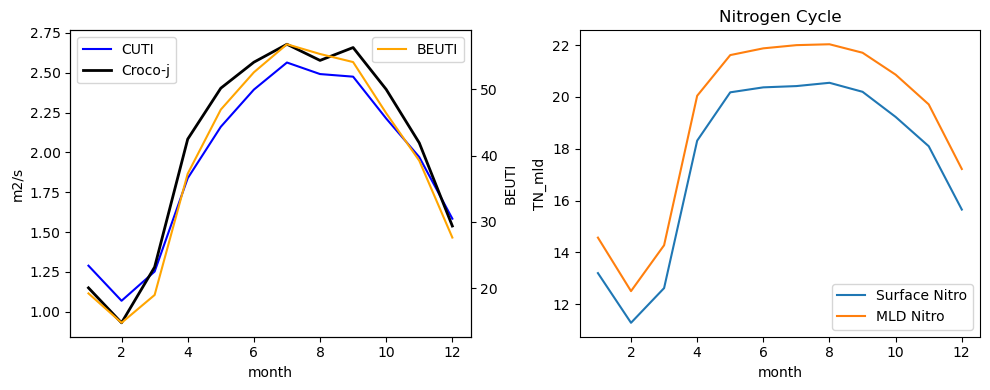

In [111]:
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# --- Top panel ---
seasonality(CUTI).sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).plot(ax=ax1, label='CUTI', color='blue')
# seasonality(wmld*250*1000).sel(lat=slice(-5,-16)).mean(dim=('lon','lat')).WMLD.rename('m/s').plot(ax=ax1, label='Croco', linewidth=2, color='black')
seasonality(wmld_*250*1000).sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).rename('m/s').plot(ax=ax1, label='Croco-j', linewidth=2, color='black')
ax1.set_ylabel('m2/s')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
seasonality(BEUTI.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band'))).plot(ax=ax2, label='BEUTI', color='orange')
ax2.set_ylabel('BEUTI')
ax2.legend(loc='upper right')

# --- Bottom panel ---
seasonality(N2.TN_surf).mean(dim=('lat','lon')).plot(ax=ax3, label='Surface Nitro')
seasonality(N2.TN_mld).mean(dim=('lat','lon')).plot(ax=ax3, label='MLD Nitro')
ax3.legend()
ax3.set_title('Nitrogen Cycle')

plt.tight_layout()

* Nitrogen input follows the upwelling season, BEUTI amplifies CUTI in seasonal scales

In [112]:
wmld_ = wmld_.rename('Croco_j')
wmld_

<xarray.DataArray 'Croco_j' (lat_band: 13, time: 432)> Size: 45kB
array([[7.48703783e-06, 4.99362218e-06, 3.99099868e-06, ...,
        8.87823721e-06, 1.21085792e-05, 6.91365426e-06],
       [3.19689482e-06, 3.09007960e-06, 3.35274337e-06, ...,
        9.75100536e-06, 5.55461086e-06, 1.64843664e-05],
       [1.81982470e-06, 2.03057560e-06, 2.59534083e-06, ...,
        4.72663730e-06, 2.62336453e-06, 2.07735914e-06],
       ...,
       [9.39129435e-06, 5.85296179e-06, 7.58446540e-06, ...,
        5.05766422e-06, 1.14146535e-05, 6.95313795e-06],
       [4.07549129e-06, 5.21954438e-06, 4.50289005e-06, ...,
        1.39201102e-05, 1.21275336e-05, 7.46220266e-06],
       [1.59082897e-06, 2.61147445e-06, 3.12940719e-06, ...,
        9.37481070e-06, 8.26715630e-06, 5.52900125e-06]])
Coordinates:
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5

In [113]:
CUTI = CUTI.to_dataset(name='CUTI')
# CUTI

In [114]:
CUTI['BEUTI'] = BEUTI
CUTI['UGEO'] = U_geo
CUTI['u_geo'] = u_geo
CUTI['U_ek'] = U_ek
CUTI['N_mld'] = N_
CUTI['CROCO_j'] = wmld_

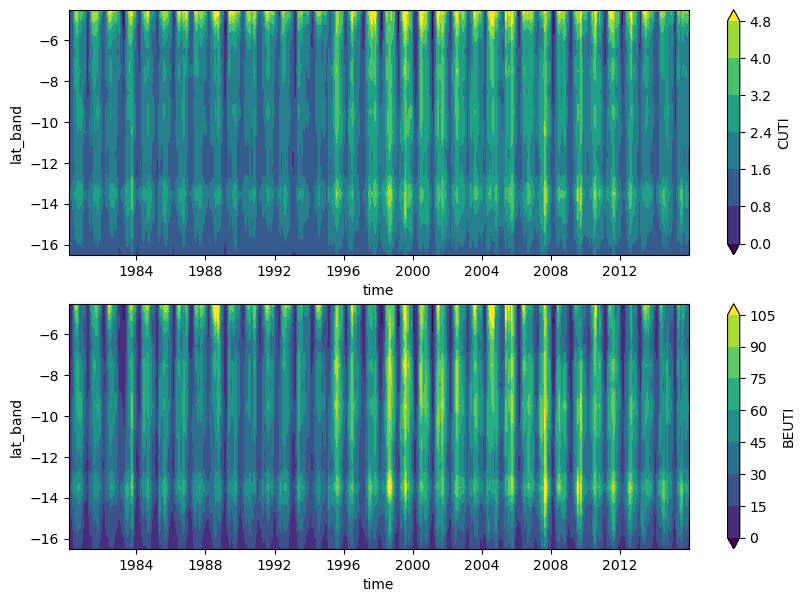

In [115]:
fig,ax = plt.subplots(2,1,figsize=(10,7))
CUTI.CUTI.plot.contourf(robust=True,ax=ax[0])
CUTI.BEUTI.plot.contourf(robust=True,ax=ax[1])

In [116]:
CUTI['cross_shore_distance'] = d
CUTI

<xarray.Dataset> Size: 318kB
Dimensions:               (time: 432, lat_band: 13)
Coordinates:
  * time                  (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
  * lat_band              (lat_band) float64 104B -4.5 -5.5 -6.5 ... -15.5 -16.5
Data variables:
    CUTI                  (lat_band, time) float64 45kB 1.684 1.146 ... 0.9979
    BEUTI                 (lat_band, time) float64 45kB 16.81 8.756 ... 7.49
    UGEO                  (lat_band, time) float64 45kB -2.529 ... -0.03756
    u_geo                 (lat_band, time) float64 45kB -0.2529 ... -0.003756
    U_ek                  (lat_band, time) float64 45kB 4.213 2.684 ... 1.035
    N_mld                 (lat_band, time) float64 45kB 9.982 7.641 ... 7.506
    CROCO_j               (lat_band, time) float64 45kB 7.487e-06 ... 5.529e-06
    cross_shore_distance  (lat_band) float64 104B 2.494e+05 ... 2.487e+05

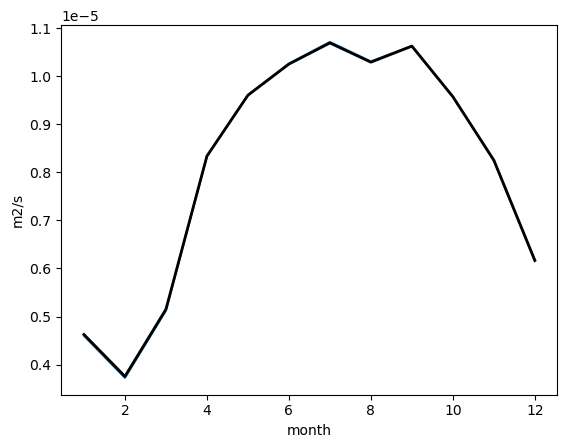

In [117]:
seasonality(CUTI).CROCO_j.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).plot()
seasonality(wmld).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).WMLD.rename('m2/s').plot(label='Croco',linewidth=2,color='black')


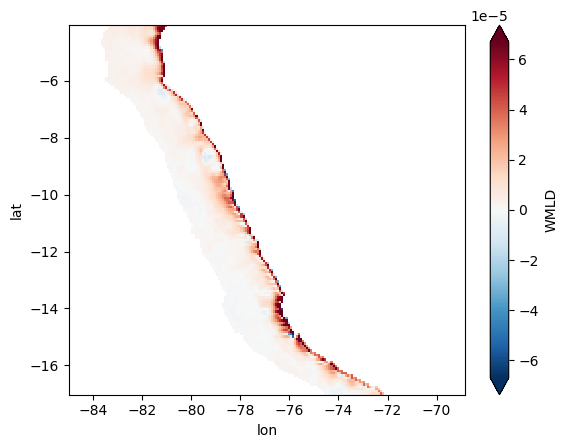

In [118]:
wmld2.mean('time').WMLD.plot(robust=True)

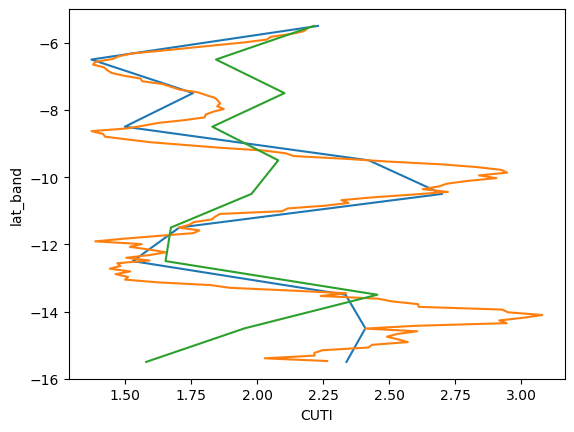

In [119]:
(CUTI*250*1000).CROCO_j.sel(lat_band=slice(-5,-16)).mean('time').plot(y='lat_band')
(wmld*250*1000).sel(lat=slice(-16,-5)).mean(dim=('lon','time')).WMLD.rolling(lat=13,center=True).mean().plot(y='lat')
CUTI.CUTI.sel(lat_band=slice(-5,-16)).mean('time').plot(y='lat_band')

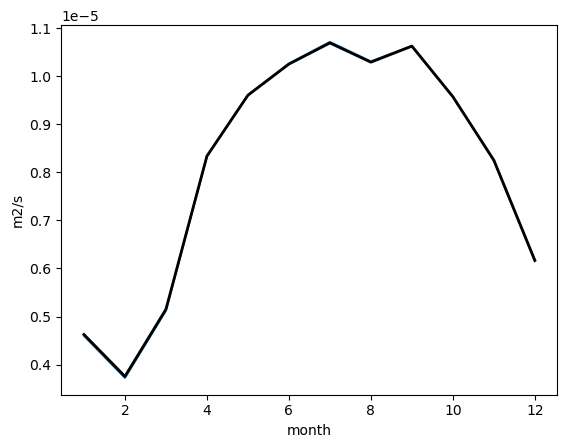

In [120]:
CUTI.CROCO_j
seasonality(CUTI).CROCO_j.sel(lat_band=slice(-5,-16)).mean(dim=('lat_band')).plot()
seasonality(wmld).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).WMLD.rename('m2/s').plot(label='Croco',linewidth=2,color='black')
